# Shared-charge MS_DSA vs contact-class asa_nz and B-factors

Groups are defined per **contact class** (`dist4.5`, `salt_bridge`, `hydrogen_bond`, `cation_pi`,
`covalent_isopeptide`, `any_bond`), computed per chain copy by `lysine_properties.py`. Each group's value comes from
one source only:

| group | peptide has a lysine with | asa_nz |
|---|---|---|
| Inter PDB | an inter-chain contact of the class in some PDB chain copy | multimer, over only those chain copies |
| Intra PDB | an intra-chain contact of the class in some PDB chain copy | multimer, over only those chain copies |
| Intra AF | an intra-chain contact of the class in the AlphaFold monomer | AlphaFold monomer |
| No contact PDB | (all lysines) no contact within 4.5 A in any PDB chain copy | multimer, over all chain copies |
| No contact AF | (all lysines) no contact within 4.5 A in the AlphaFold monomer | AlphaFold monomer |

Statistics over chain copies and lysines: **max** = max of max, **min** = min of min, **avg** = average over lysines
of the per-lysine mean. Two comparisons: intra groups **may also be inter-chain**, or **purely intra** (no peptide
lysine with an inter-chain bond, `pdb_inter_any_bond`). Inter PDB may also be intra-chain in both.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dsa.ms_dsa.evaluation1.ms_dsa_annotator import MSDSAAnnotator
from dsa.ms_dsa.evaluation1.lysine_properties import CONTACT_CLASSES
from dsa.ms_dsa.evaluation1.plots import class_groups, group_scatter, group_histogram, group_sizes, group_correlations, plot_runs

plt.rcParams.update({"font.size": 8, "figure.dpi": 100})

RUN_INDICES = range(5)
ms_dsa_by_run = {run_index: MSDSAAnnotator.load_run(run_index) for run_index in RUN_INDICES}
print("contact classes:", CONTACT_CLASSES)

contact classes: ['dist4.5', 'salt_bridge', 'hydrogen_bond', 'cation_pi', 'covalent_isopeptide', 'any_bond']


In [2]:
# settings
dsa_column = "MS_DSA_shared_charges"
contact_class = "salt_bridge"          # one of CONTACT_CLASSES
versions = {
    "A. zero areas included": ["channel_absent", "no_shared_charges"],
    "B. zero areas excluded": ["channel_absent", "no_shared_charges", "zero_area_shared"],
}
version = "A. zero areas included"
exclude = versions[version]

sasa_bins = [*np.arange(0.0, 61.0, 10.0), np.inf]                 # asa_nz, width 10
bfactor_bins = [-np.inf, *np.arange(-3.0, 5.5, 1.0), np.inf]       # B-factor z-scores, width 1
comparisons = {"intra may also be inter": False, "purely intra": True}

In [3]:
# peptides per group (with a shared-charge MS_DSA and an asa_nz value) for every contact class, run 0
pd.DataFrame({c: group_sizes({0: ms_dsa_by_run[0]}, class_groups(c, "max"), dsa_column, exclude).iloc[0]
              for c in CONTACT_CLASSES}).T

,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
dist4.5,321,738,856,80,681
salt_bridge,106,404,472,80,681
hydrogen_bond,218,548,595,80,681
cation_pi,42,163,65,80,681
covalent_isopeptide,0,0,0,80,681
any_bond,227,587,626,80,681


## asa_nz by contact class

salt_bridge, asa_nz max, intra may also be inter - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,0.034,0.065,0.042,0.023,-0.032
1,-0.052,0.071,0.059,0.112,0.042
2,0.044,0.036,0.069,0.051,-0.044
3,-0.113,0.070,0.062,-0.032,0.057
4,0.006,0.047,0.055,-0.057,0.038


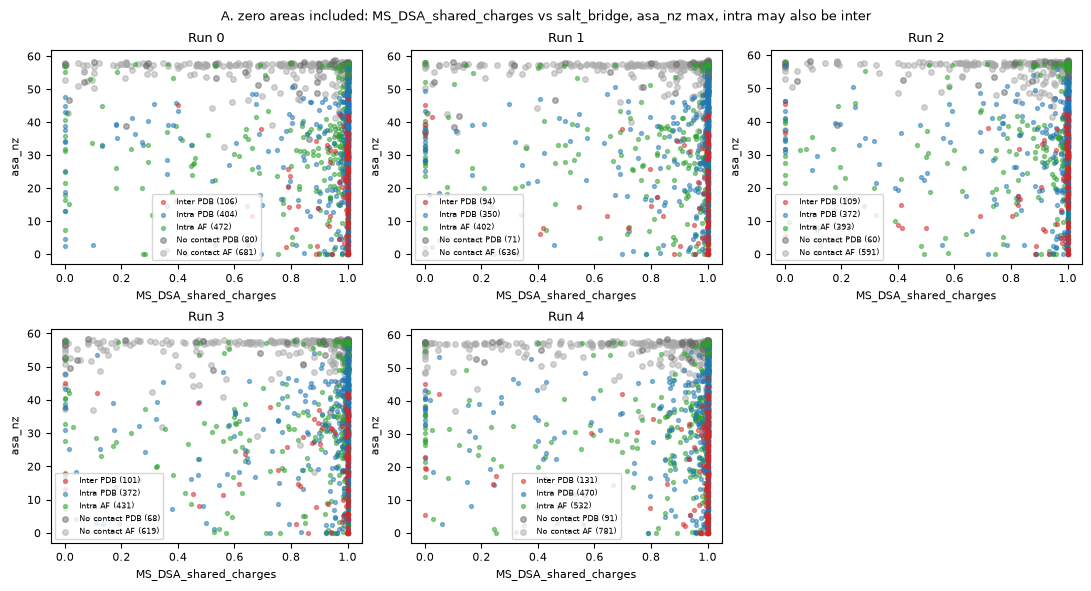

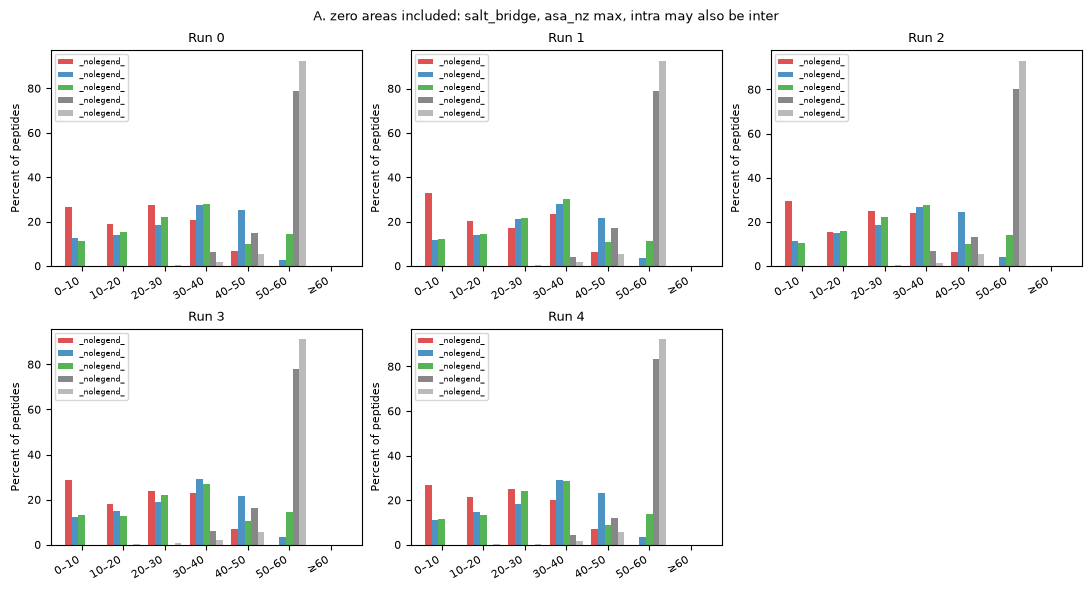

salt_bridge, asa_nz min, intra may also be inter - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,-0.052,-0.066,-0.012,-0.017,-0.096
1,-0.104,-0.048,0.047,0.060,0.010
2,-0.037,-0.043,0.014,0.020,-0.092
3,-0.167,-0.030,0.029,-0.064,-0.006
4,-0.027,-0.023,-0.056,-0.050,0.021


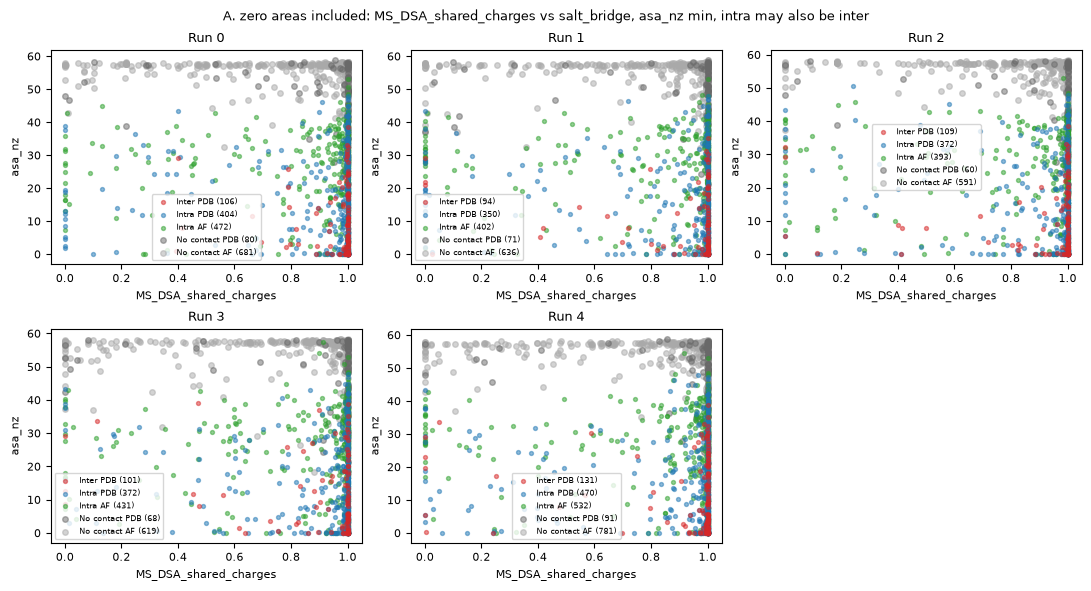

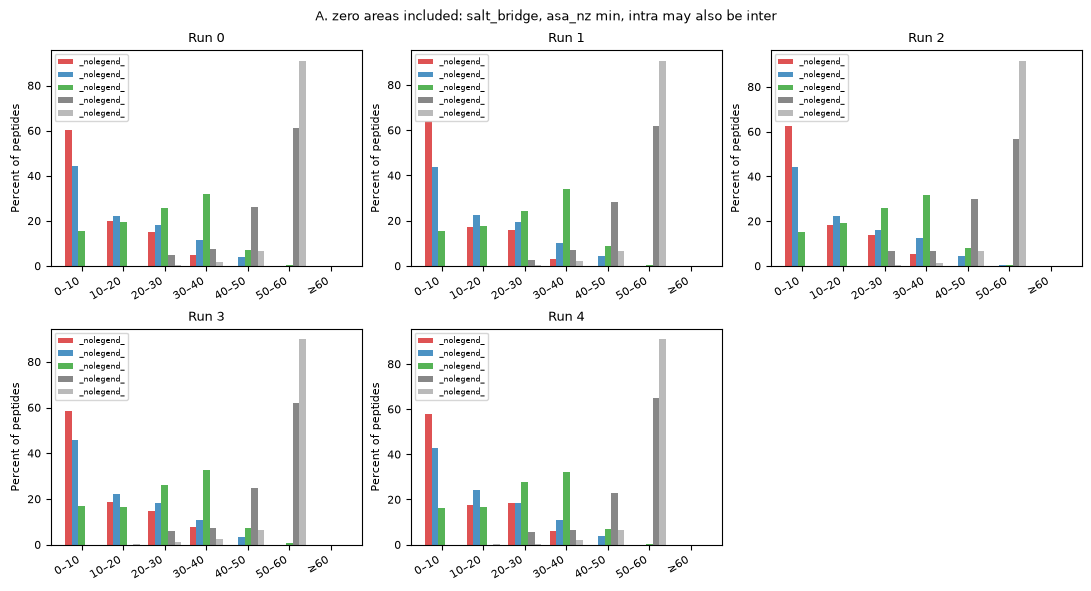

salt_bridge, asa_nz avg, intra may also be inter - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,0.006,0.006,0.021,0.018,-0.076
1,-0.095,0.032,0.048,0.097,0.018
2,0.032,-0.008,0.049,0.066,-0.077
3,-0.174,0.032,0.054,-0.048,0.012
4,-0.002,0.009,0.010,-0.052,0.029


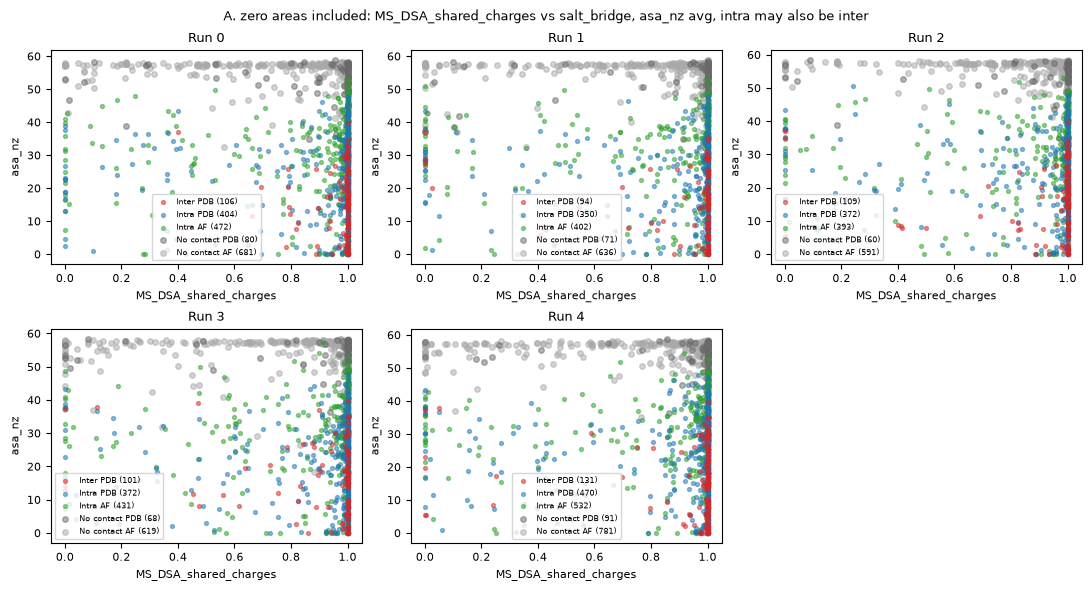

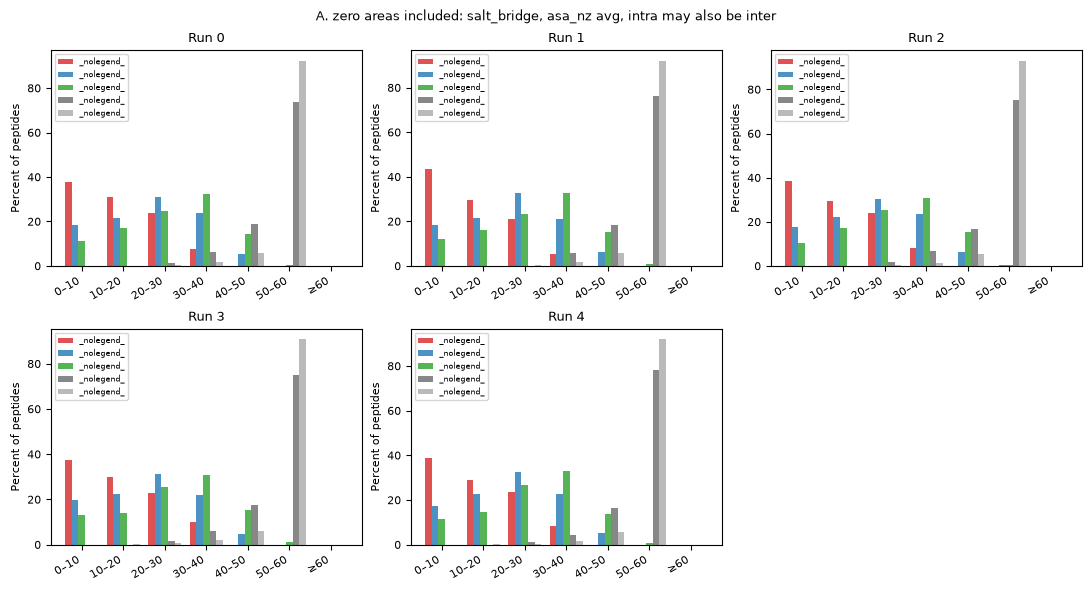

salt_bridge, asa_nz max, purely intra - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,0.034,0.056,0.056,0.023,-0.032
1,-0.052,0.042,0.083,0.112,0.042
2,0.044,0.037,0.074,0.051,-0.044
3,-0.113,0.077,0.086,-0.032,0.057
4,0.006,0.083,0.040,-0.057,0.038


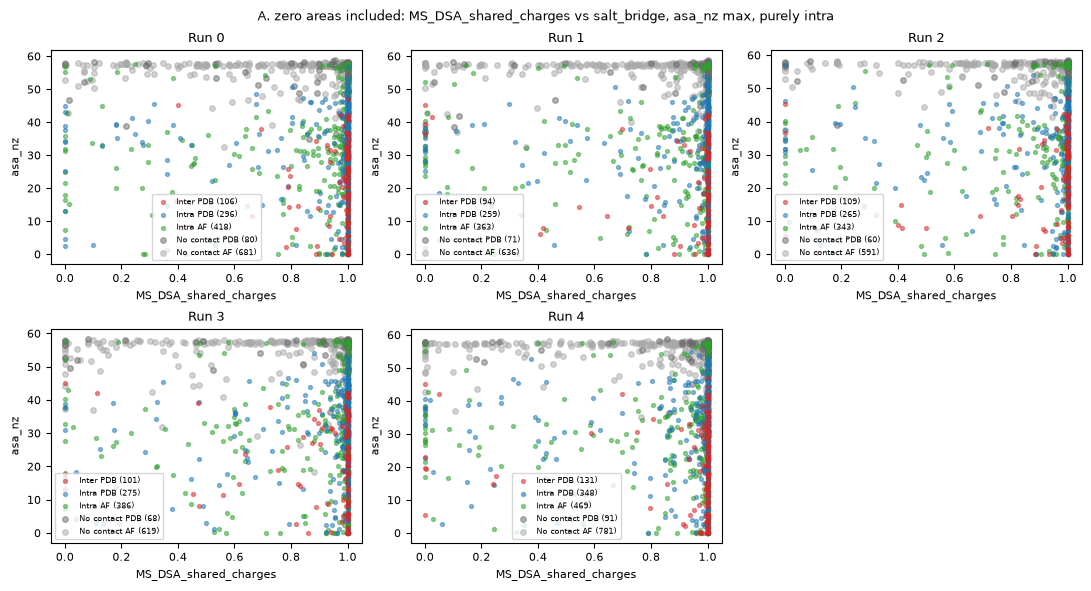

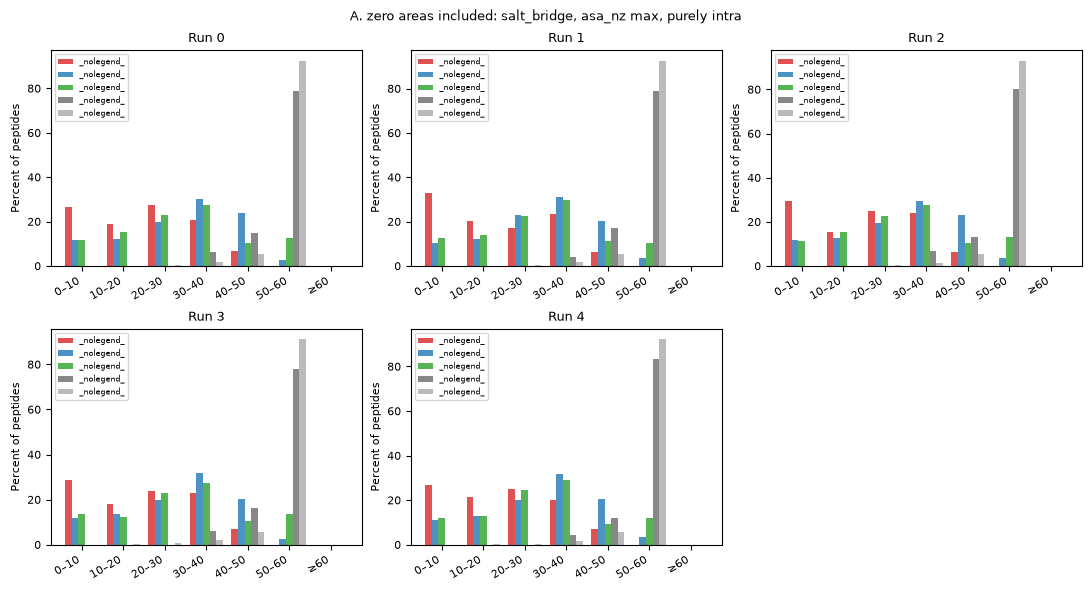

salt_bridge, asa_nz min, purely intra - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,-0.052,-0.043,-0.008,-0.017,-0.096
1,-0.104,-0.057,0.050,0.060,0.010
2,-0.037,-0.039,0.023,0.020,-0.092
3,-0.167,-0.001,0.040,-0.064,-0.006
4,-0.027,0.019,-0.035,-0.050,0.021


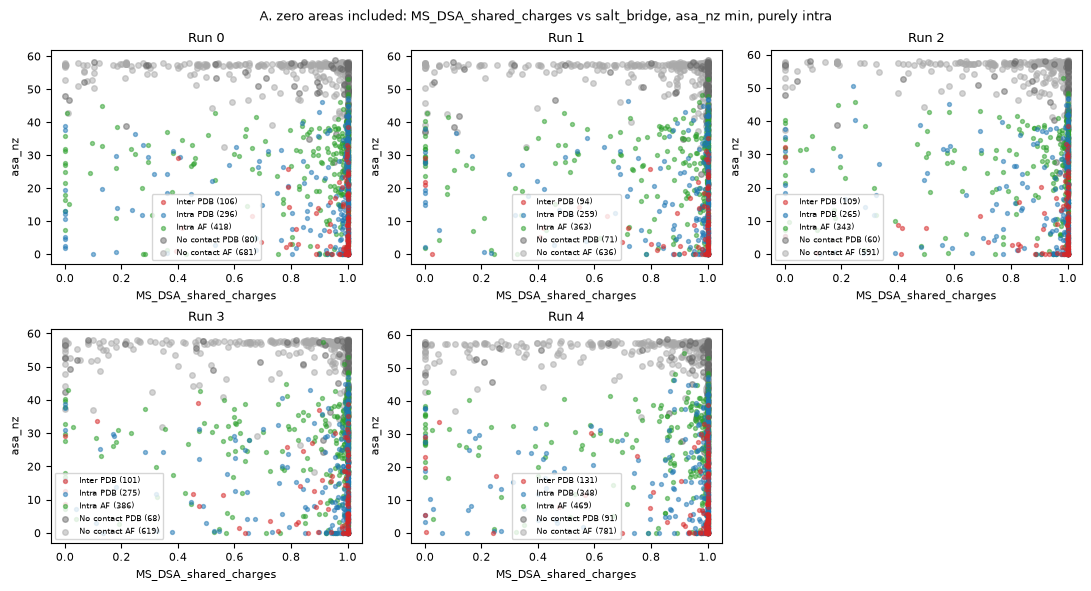

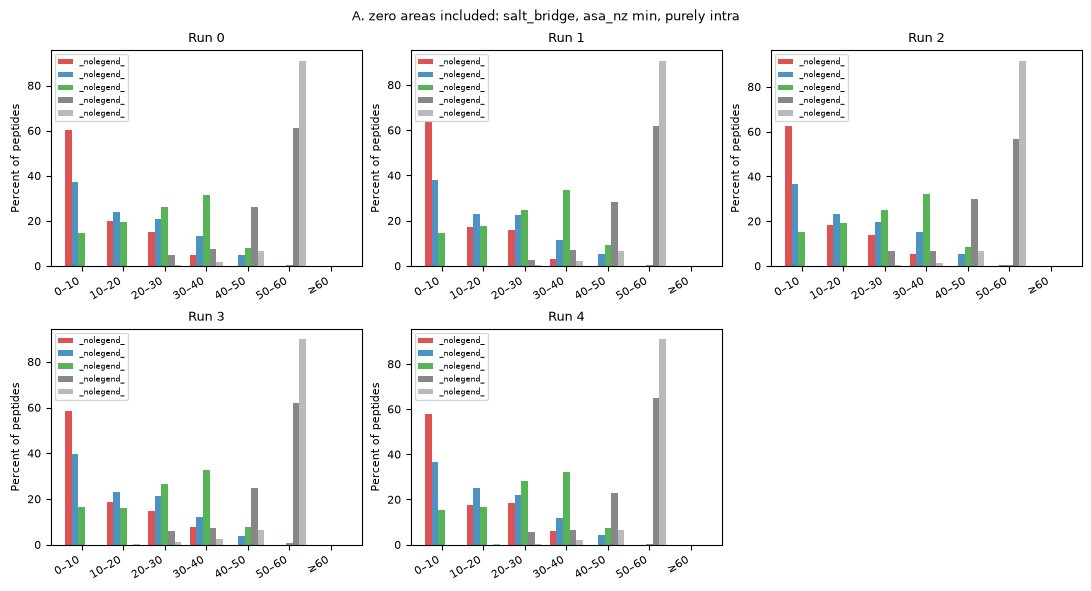

salt_bridge, asa_nz avg, purely intra - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,0.006,0.010,0.034,0.018,-0.076
1,-0.095,0.003,0.069,0.097,0.018
2,0.032,0.002,0.058,0.066,-0.077
3,-0.174,0.040,0.077,-0.048,0.012
4,-0.002,0.055,0.012,-0.052,0.029


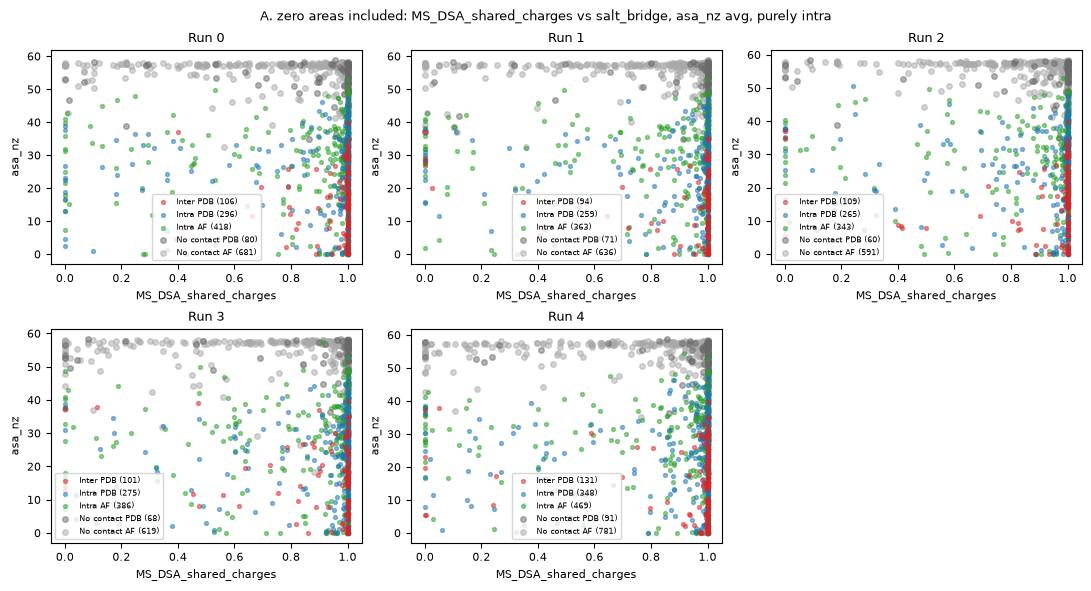

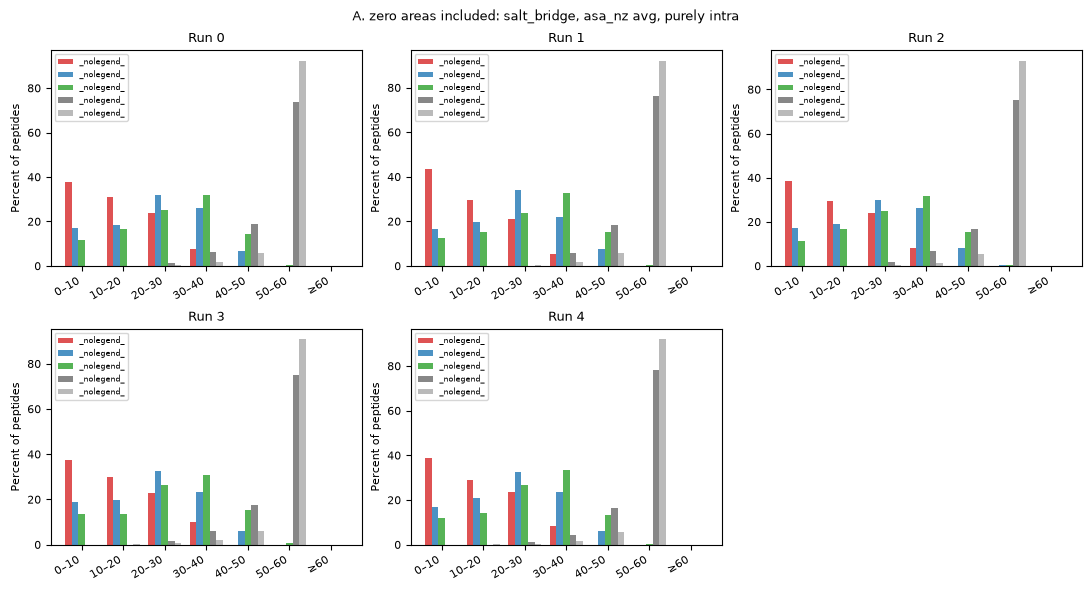

In [4]:
for comparison, purely_intra in comparisons.items():
    for statistic in ("max", "min", "avg"):
        groups = class_groups(contact_class, statistic, purely_intra=purely_intra)
        title = f"{contact_class}, asa_nz {statistic}, {comparison}"
        print(f"{title} - Spearman correlation with {dsa_column}")
        display(group_correlations(ms_dsa_by_run, groups, dsa_column, exclude))
        plot_runs(ms_dsa_by_run, group_scatter, groups=groups, dsa_column=dsa_column, exclude=exclude,
                  title=f"{dsa_column} vs {title}", suptitle=f"{version}: {dsa_column} vs {title}")
        plt.show()
        plot_runs(ms_dsa_by_run, group_histogram, groups=groups, bins=sasa_bins, dsa_column=dsa_column, exclude=exclude,
                  title=title, suptitle=f"{version}: {title}")
        plt.show()

## B-factors by contact class

B-factors do not depend on the contact class (z-score of the lysine over all its PDB chains); they are plotted for
the peptides of each group. AlphaFold groups also use the PDB B-factor when the lysine is in a PDB structure.

salt_bridge, B-factor NZ max (nz_bfactor_z_max_max), intra may also be inter - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,0.175,0.069,0.054,-0.040,0.029
1,0.123,0.031,0.006,0.030,-0.032
2,0.063,0.062,0.010,0.012,0.010
3,-0.001,0.005,-0.022,0.015,-0.084
4,0.017,0.019,-0.003,-0.137,0.027


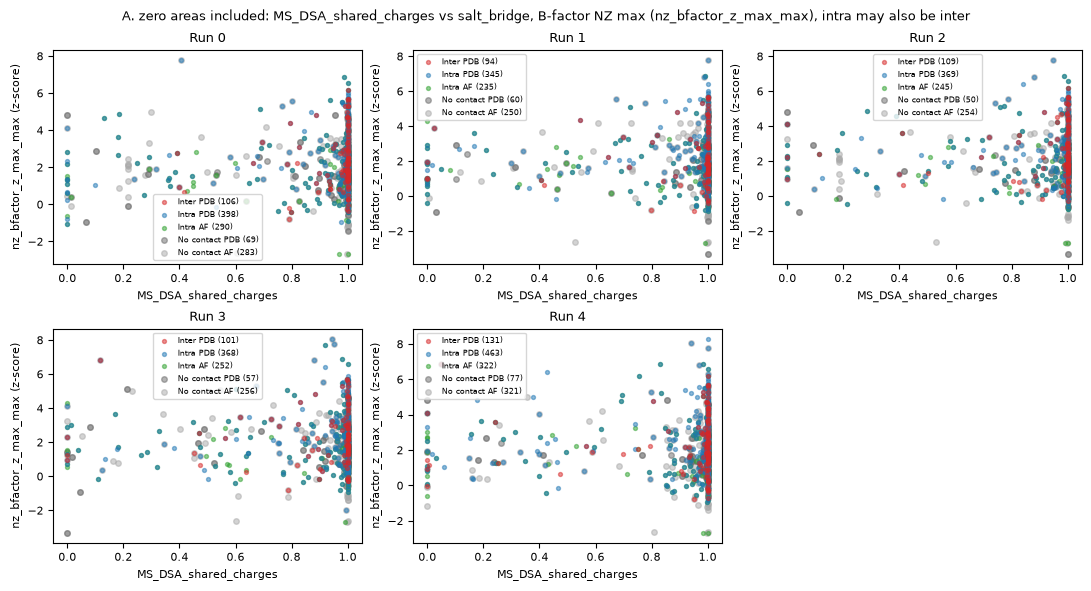

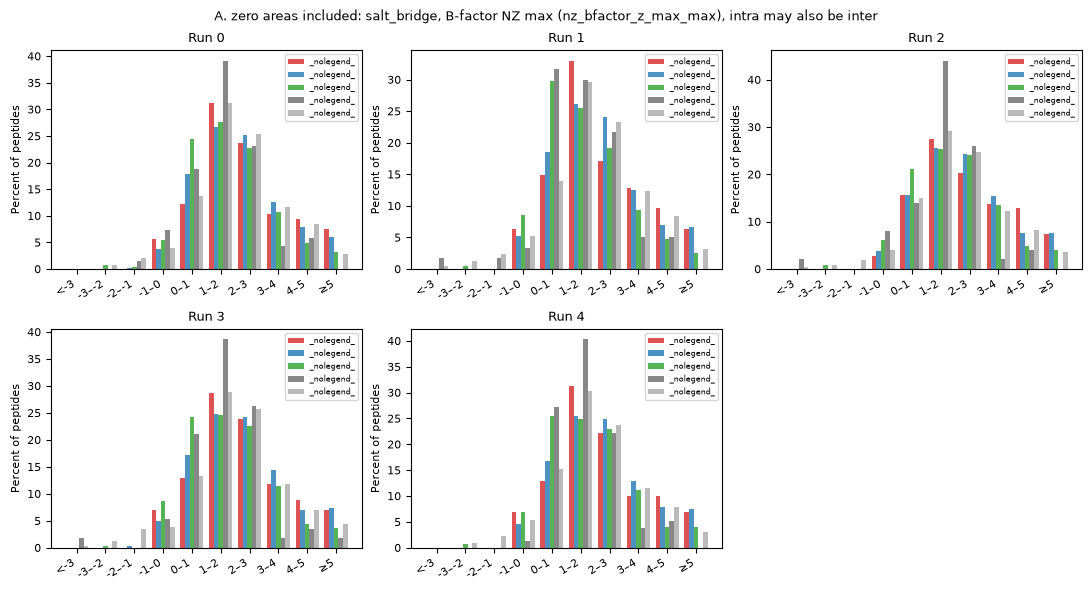

salt_bridge, B-factor NZ min (nz_bfactor_z_min_min), intra may also be inter - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,-0.125,0.036,0.041,-0.099,0.018
1,-0.165,-0.015,-0.045,0.038,0.054
2,0.015,0.054,0.131,-0.022,0.019
3,-0.096,-0.011,-0.035,-0.045,0.012
4,-0.124,0.020,0.030,-0.149,0.040


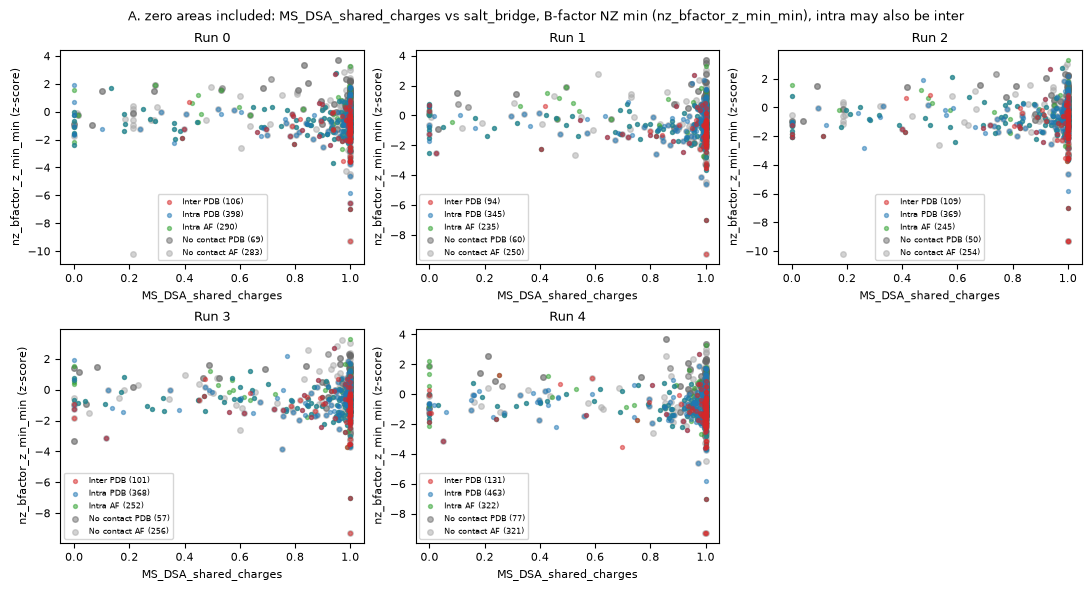

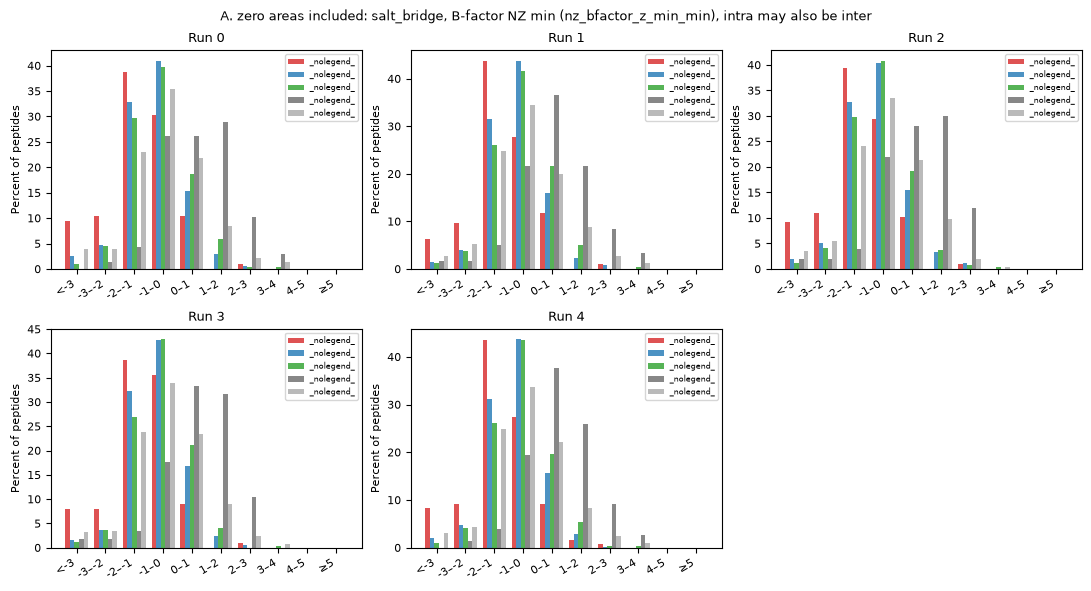

salt_bridge, B-factor residue max (avg_bfactor_z_mean_max), intra may also be inter - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,0.043,0.081,0.065,-0.050,-0.036
1,-0.077,-0.004,-0.012,0.008,-0.008
2,0.050,0.118,0.081,-0.055,-0.035
3,-0.100,0.023,-0.001,-0.081,-0.136
4,-0.046,0.044,0.039,-0.193,-0.019


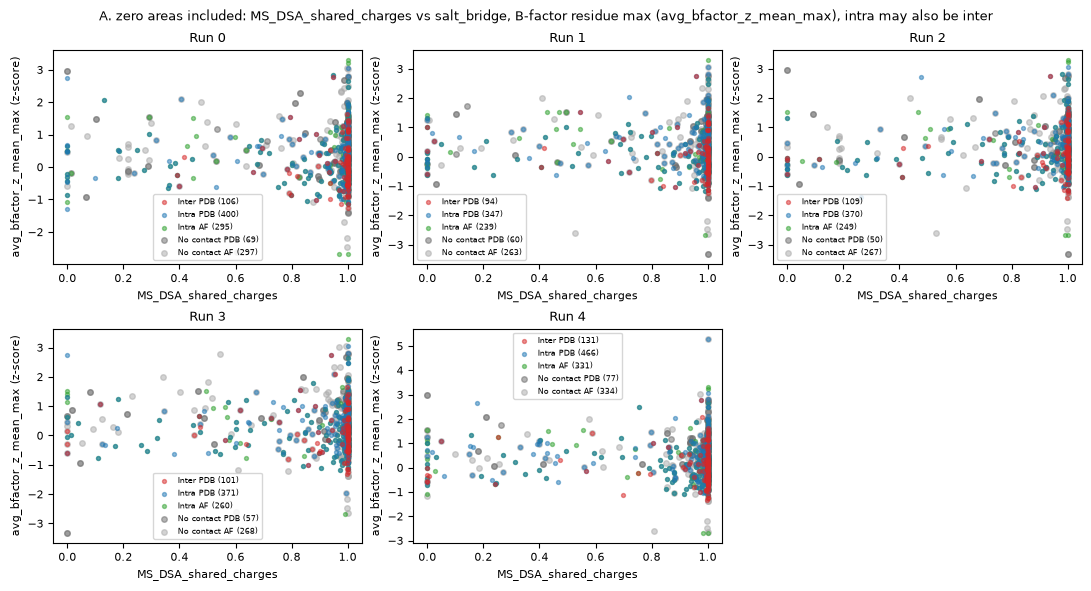

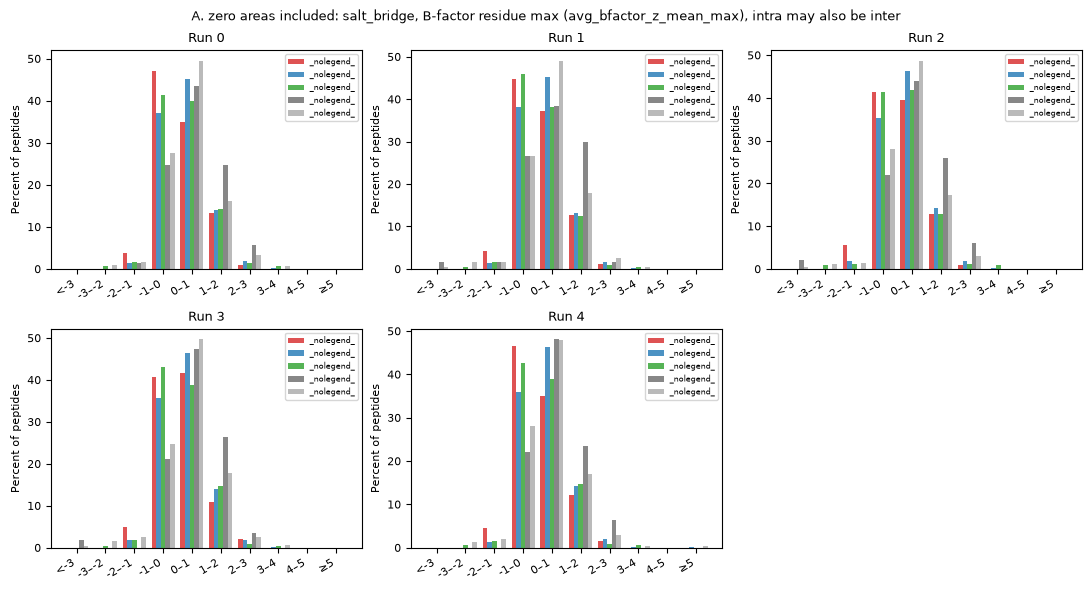

salt_bridge, B-factor residue min (avg_bfactor_z_mean_min), intra may also be inter - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,-0.013,0.064,0.054,-0.075,-0.055
1,-0.093,-0.036,-0.039,-0.043,-0.022
2,-0.007,0.096,0.056,-0.071,-0.063
3,-0.176,-0.011,-0.054,-0.112,-0.149
4,-0.067,0.020,-0.021,-0.232,-0.024


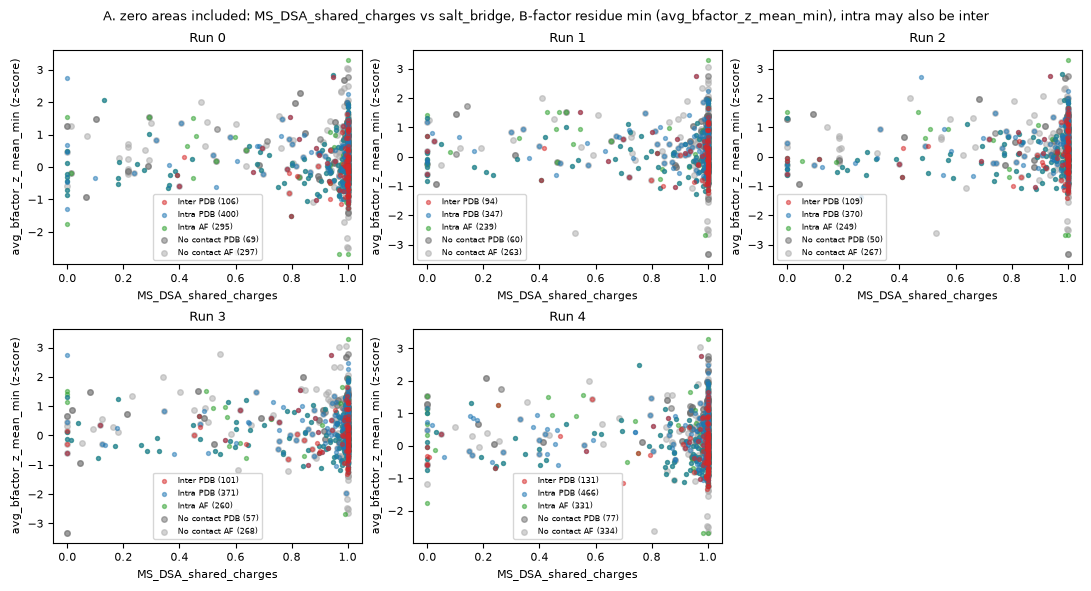

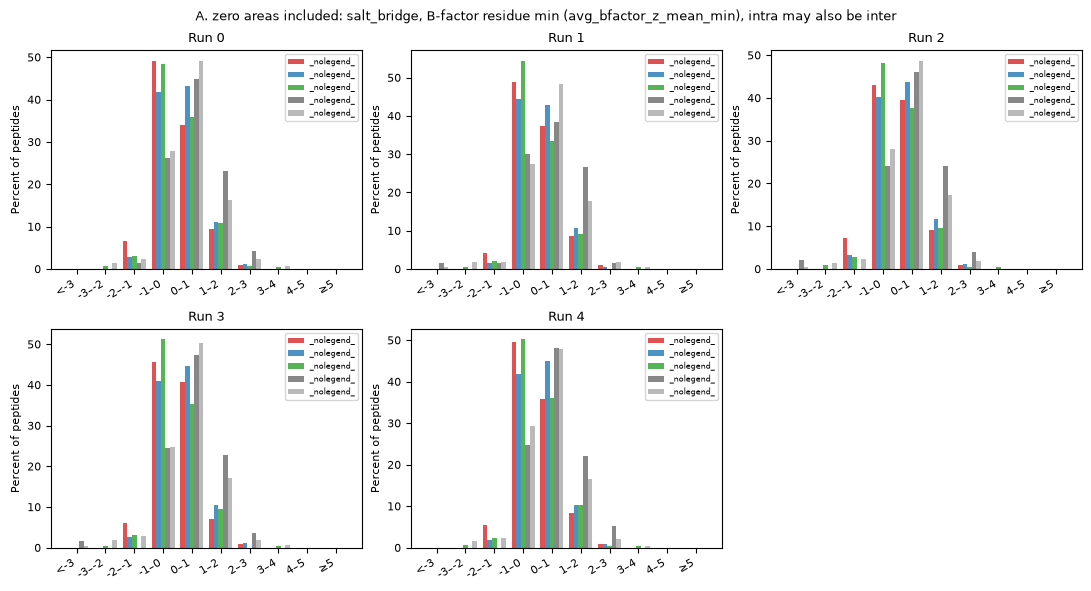

salt_bridge, B-factor NZ max (nz_bfactor_z_max_max), purely intra - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,0.175,0.042,0.001,-0.040,0.029
1,0.123,0.045,-0.022,0.030,-0.032
2,0.063,0.050,-0.018,0.012,0.010
3,-0.001,0.007,-0.063,0.015,-0.084
4,0.017,0.036,-0.013,-0.137,0.027


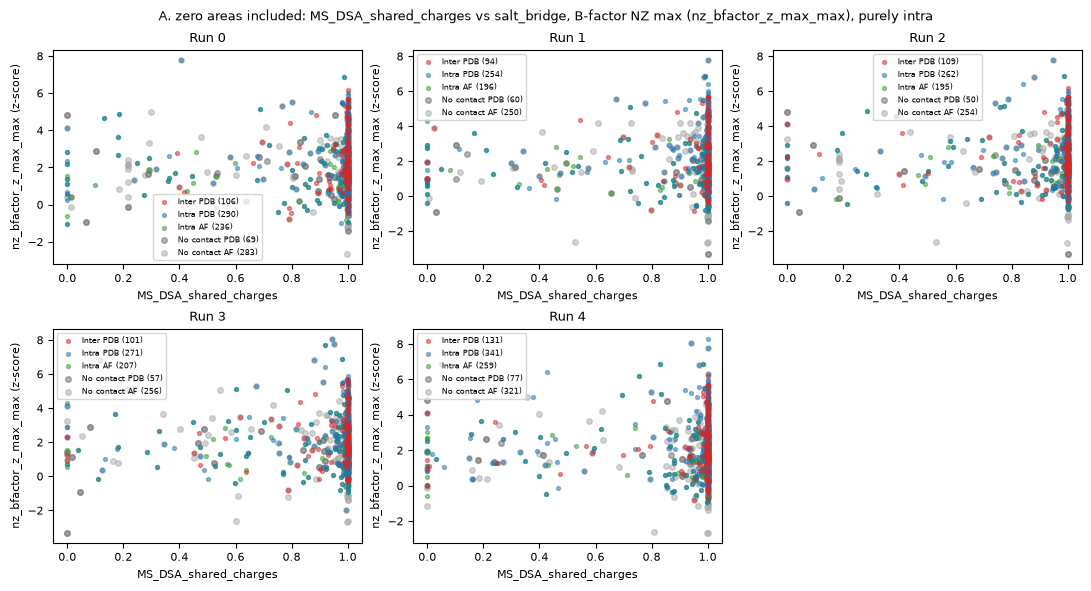

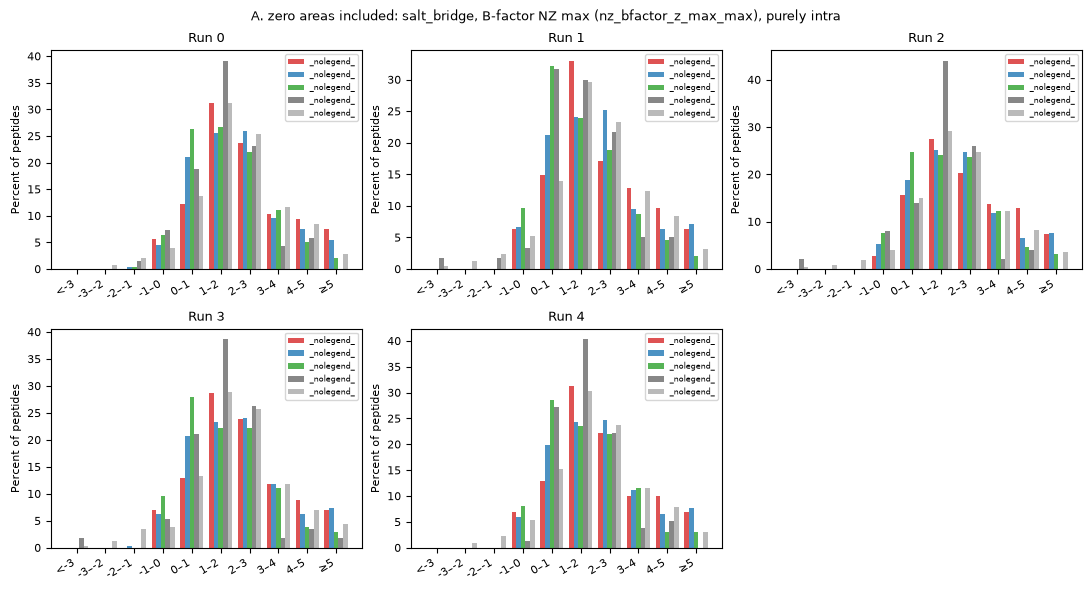

salt_bridge, B-factor NZ min (nz_bfactor_z_min_min), purely intra - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,-0.125,0.034,0.034,-0.099,0.018
1,-0.165,0.008,-0.035,0.038,0.054
2,0.015,0.084,0.134,-0.022,0.019
3,-0.096,-0.021,-0.021,-0.045,0.012
4,-0.124,0.064,0.071,-0.149,0.040


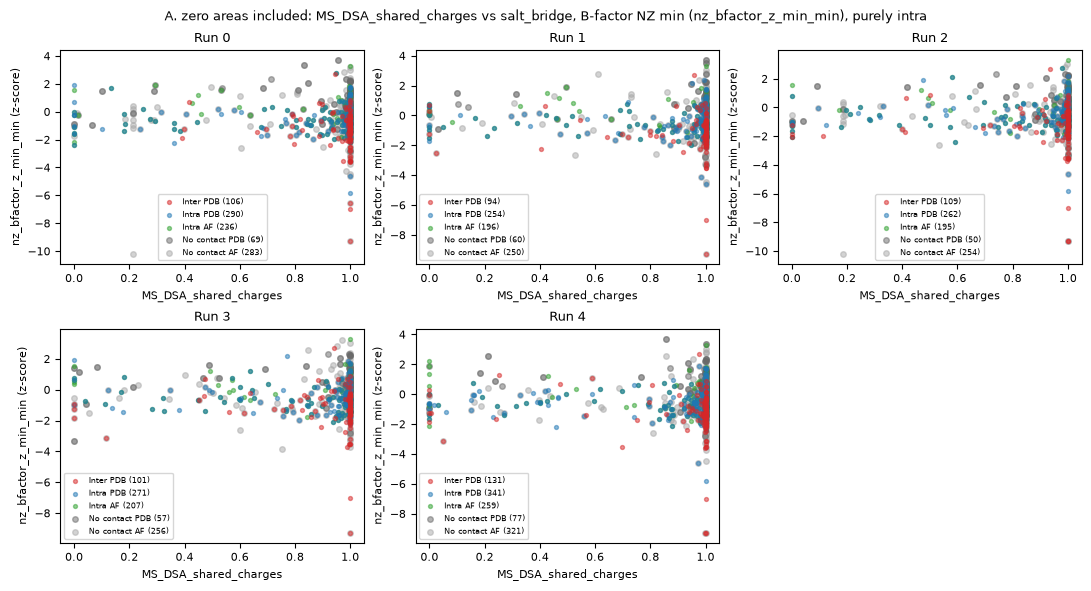

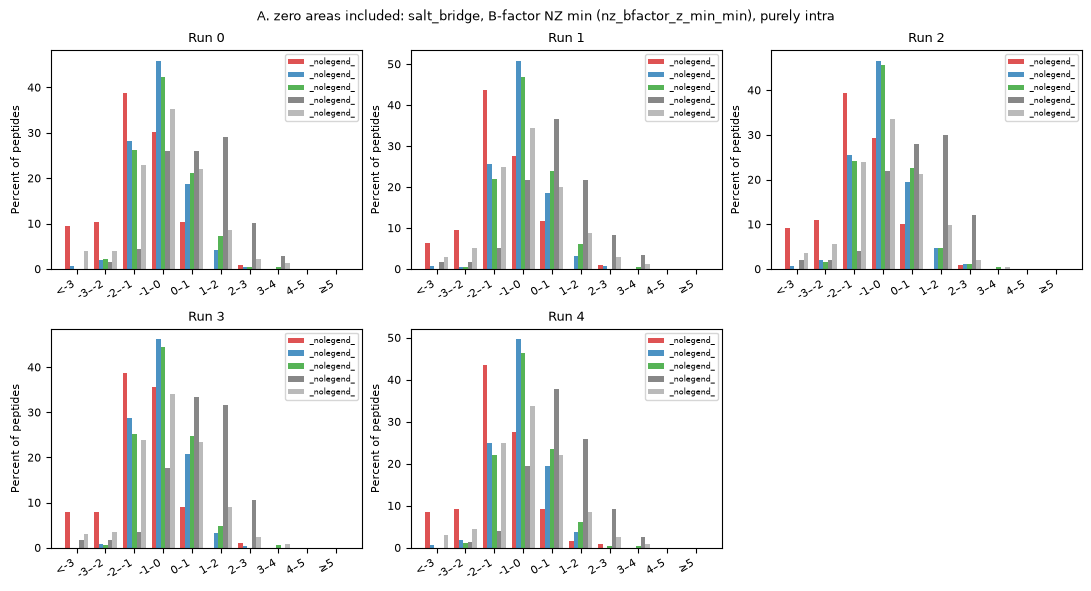

salt_bridge, B-factor residue max (avg_bfactor_z_mean_max), purely intra - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,0.043,0.046,-0.000,-0.050,-0.036
1,-0.077,0.012,-0.029,0.008,-0.008
2,0.050,0.112,0.018,-0.055,-0.035
3,-0.100,0.028,-0.037,-0.081,-0.136
4,-0.046,0.047,0.000,-0.193,-0.019


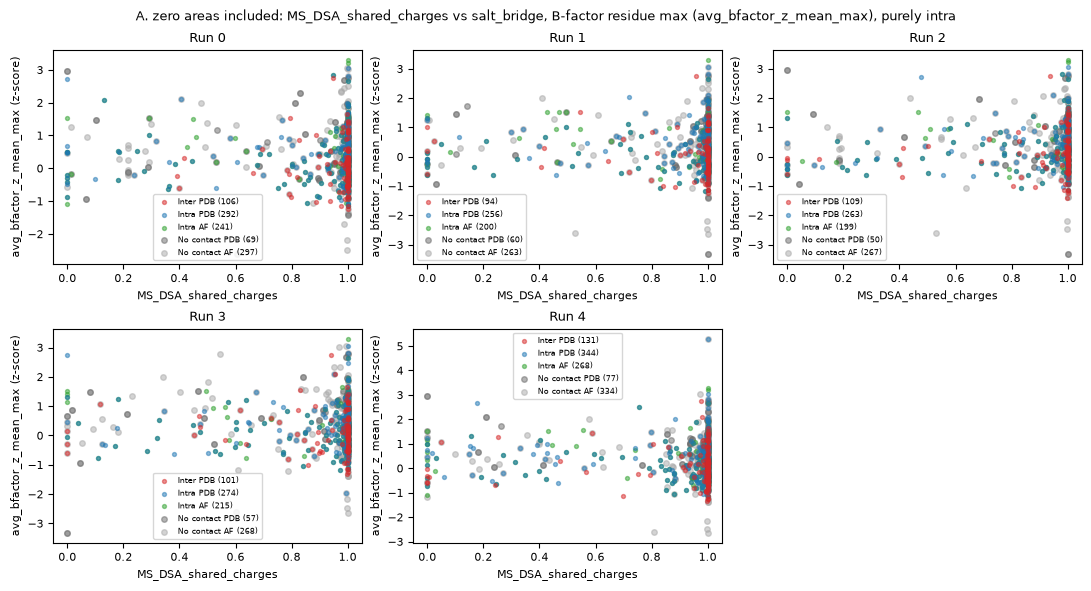

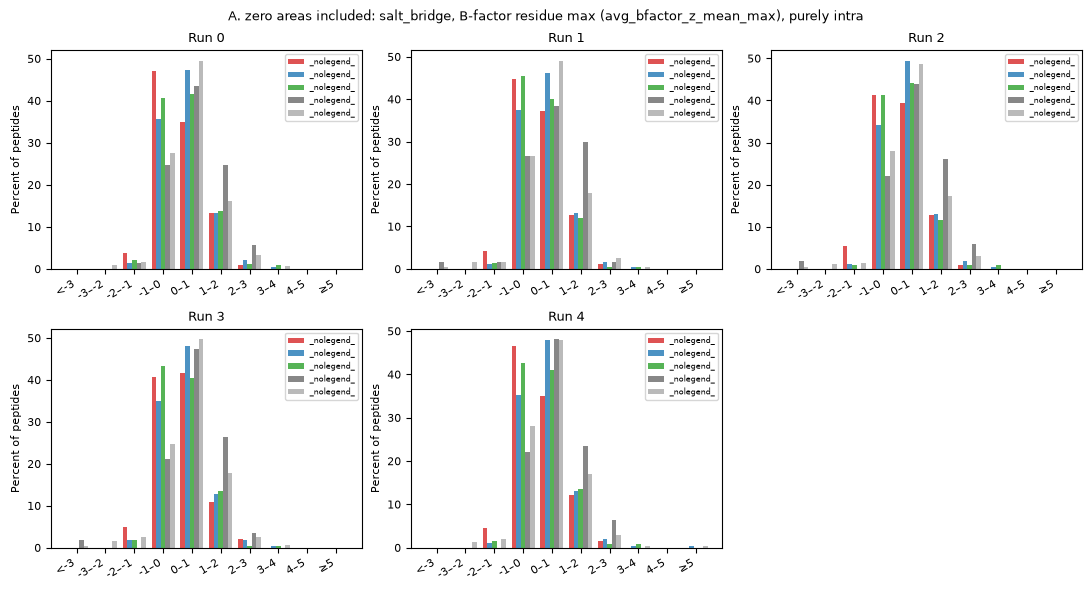

salt_bridge, B-factor residue min (avg_bfactor_z_mean_min), purely intra - Spearman correlation with MS_DSA_shared_charges


,Inter PDB,Intra PDB,Intra AF,No contact PDB,No contact AF
run,,,,,
0,-0.013,0.054,0.001,-0.075,-0.055
1,-0.093,-0.020,-0.070,-0.043,-0.022
2,-0.007,0.123,0.019,-0.071,-0.063
3,-0.176,0.018,-0.072,-0.112,-0.149
4,-0.067,0.034,-0.042,-0.232,-0.024


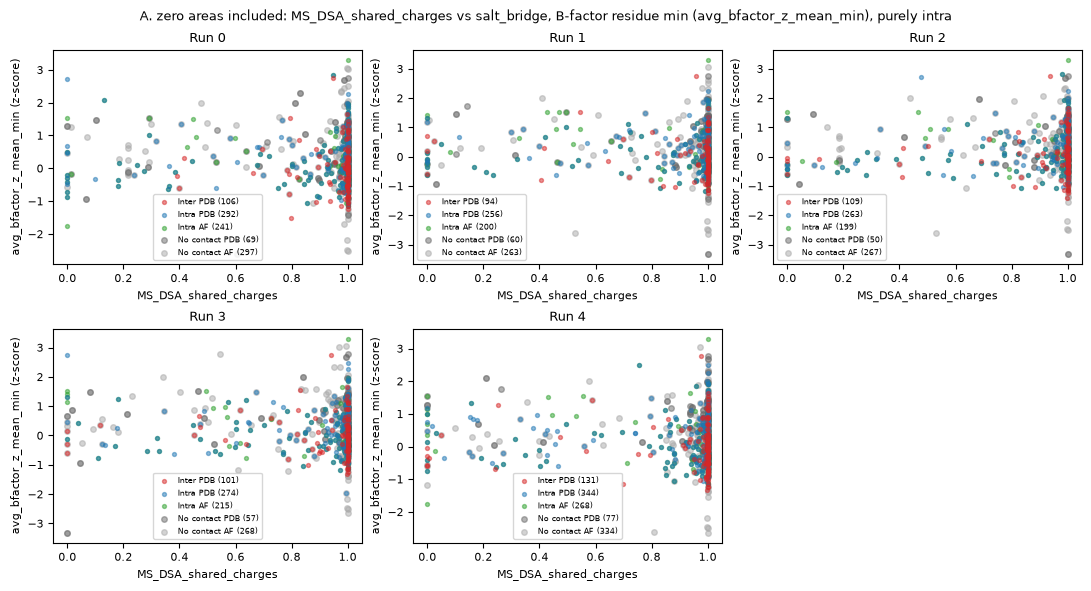

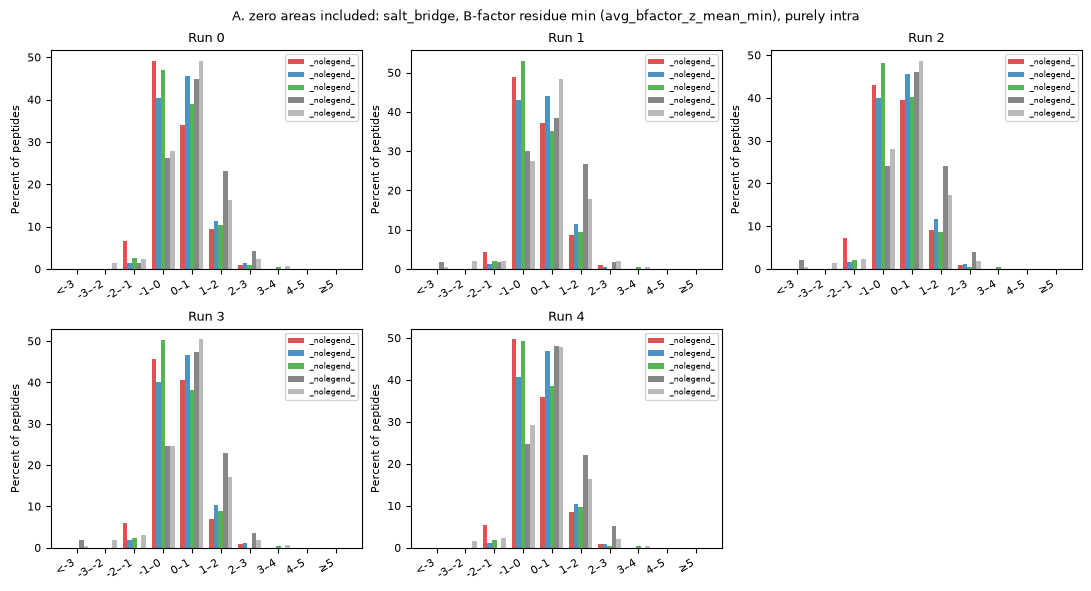

In [5]:
bfactor_columns = {"NZ max": "nz_bfactor_z_max_max", "NZ min": "nz_bfactor_z_min_min",
                   "residue max": "avg_bfactor_z_mean_max", "residue min": "avg_bfactor_z_mean_min"}
for comparison, purely_intra in comparisons.items():
    for name, column in bfactor_columns.items():
        groups = class_groups(contact_class, purely_intra=purely_intra,
                              value_columns={g: column for g in ["Inter PDB", "Intra PDB", "Intra AF", "No contact PDB", "No contact AF"]})
        title = f"{contact_class}, B-factor {name} ({column}), {comparison}"
        print(f"{title} - Spearman correlation with {dsa_column}")
        display(group_correlations(ms_dsa_by_run, groups, dsa_column, exclude))
        plot_runs(ms_dsa_by_run, group_scatter, groups=groups, dsa_column=dsa_column, exclude=exclude,
                  title=title, ylabel=f"{column} (z-score)", suptitle=f"{version}: {dsa_column} vs {title}")
        plt.show()
        plot_runs(ms_dsa_by_run, group_histogram, groups=groups, bins=bfactor_bins, dsa_column=dsa_column, exclude=exclude,
                  title=title, suptitle=f"{version}: {title}")
        plt.show()